# Prism: AI-Assisted Anomaly Prioritisation in Operational Data

**AIBUILD Challenge 1 · Launch Melbourne**

## Project Overview

Operational teams often collect large volumes of equipment data but have limited time to investigate every record. Dashboards show what happened; they do not tell a maintenance planner which of thousands of readings deserve attention first.

Prism is a prototype that:

1. **identifies** unusual operating conditions;
2. **ranks** every record by how unusual it is and assigns a severity tier; and
3. **explains** in plain language why each record was flagged.

The prototype uses the public, synthetic **AI4I 2020 Predictive Maintenance** dataset (10,000 records). Machine-failure labels are **never used to train or score** the model. They are reserved for evaluating whether the unsupervised ranking places real failures near the top.

### Notebook structure

1. Data understanding and quality checks
2. Exploratory analysis
3. Baseline model: Isolation Forest V1
4. Refinement: Isolation Forest V2 (operational features only)
5. Benchmarking against simpler and alternative methods
6. Holdout check on unseen records
7. Final model: the Prism Score
8. Prioritisation and severity tiers
9. Explainability
10. Validation and impact
11. False positives
12. Scoring new records
13. Final outputs and exports
14. Conclusion and limitations

## Setup

The notebook runs in Google Colab (reading from Google Drive) or locally. In Colab, place `ai4i2020.csv` in `MyDrive/HEX/`. Locally, place it next to this notebook. All charts and exports are written to a `prism_outputs` folder in the same location.

In [1]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/HEX")
except ImportError:
    BASE_DIR = Path(".")

DATA_PATH = BASE_DIR / "ai4i2020.csv"
OUTPUT_DIR = BASE_DIR / "prism_outputs"
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Download ai4i2020.csv from the UCI Machine "
        "Learning Repository (dataset 601) and place it in that folder."
    )
print("Data:", DATA_PATH)
print("Outputs:", OUTPUT_DIR)

Data: ai4i2020.csv
Outputs: prism_outputs


In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

### Shared helpers

`evaluate_ranking` is used for every model so that all comparisons are made the same way. It sorts records by score (highest = most unusual) and reports, for each Top-N cut-off, how many recorded failures were found, the failure rate, recall, and enrichment over the dataset baseline.

The `deck_axes` and `save_chart` helpers produce charts styled to match the Prism pitch deck and save them as PNGs for the slides.

In [3]:
TOP_N_VALUES = [20, 50, 100, 200, 339, 500, 1000]


def evaluate_ranking(df, score, top_n_values=TOP_N_VALUES):
    """Evaluate a ranking against recorded failures.

    score: a column name in df or an array aligned with df (higher = more unusual).
    Failure labels are only read here, after scoring.
    """
    s = df[score] if isinstance(score, str) else pd.Series(np.asarray(score), index=df.index)
    order = s.sort_values(ascending=False, kind="mergesort").index
    y = df.loc[order, "Machine failure"]
    total = df["Machine failure"].sum()
    baseline = df["Machine failure"].mean()

    rows = []
    for n in top_n_values:
        found = int(y.iloc[:n].sum())
        rows.append({
            "Top N": n,
            "Failures Found": found,
            "Failure Rate (%)": round(found / n * 100, 1),
            "Recall (%)": round(found / total * 100, 1),
            "Enrichment vs Baseline": round(found / n / baseline, 1),
        })
    return pd.DataFrame(rows)


def failures_found(df, score, n):
    return int(evaluate_ranking(df, score, [n])["Failures Found"].iloc[0])


DECK = {
    "bg": "#0B0A3A", "fg": "#FFFFFF", "muted": "#A9A8D6",
    "yellow": "#F5C542", "cyan": "#3DD6F5", "purple": "#7B5CFF",
    "grey": "#6E6D99", "red": "#FF6B6B",
}


def deck_axes(figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize, facecolor=DECK["bg"])
    ax.set_facecolor(DECK["bg"])
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(DECK["muted"])
    ax.tick_params(colors=DECK["fg"], labelsize=11)
    ax.xaxis.label.set_color(DECK["fg"])
    ax.yaxis.label.set_color(DECK["fg"])
    ax.title.set_color(DECK["fg"])
    return fig, ax


def style_legend(ax, **kwargs):
    leg = ax.legend(frameon=False, **kwargs)
    for text in leg.get_texts():
        text.set_color(DECK["fg"])
    return leg


def save_chart(fig, name):
    path = CHART_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved {path}")

## 1. Data Understanding and Quality Checks

In [4]:
ai4i = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
ai4i.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
ai4i.shape

(10000, 14)

In [6]:
ai4i.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [7]:
# Check for null values
ai4i.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
# Target variable counts
ai4i["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [9]:
ai4i[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [10]:
ai4i["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [11]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

ai4i["failure_type_count"] = ai4i[failure_cols].sum(axis=1)

pd.crosstab(ai4i["Machine failure"], ai4i["failure_type_count"])

failure_type_count,0,1,2,3
Machine failure,,,,
0,9643,18,0,0
1,9,306,23,1


In [12]:
mismatch = ai4i[
    ((ai4i["Machine failure"] == 0) & (ai4i["failure_type_count"] > 0)) |
    ((ai4i["Machine failure"] == 1) & (ai4i["failure_type_count"] == 0))
]

mismatch[["UDI", "Product ID", "Machine failure",
          "TWF", "HDF", "PWF", "OSF", "RNF", "failure_type_count"]]

,UDI,Product ID,Machine failure,TWF,HDF,PWF,OSF,RNF,failure_type_count
1221,1222,M16081,0,0,0,0,0,1,1
1302,1303,L48482,0,0,0,0,0,1,1
1437,1438,H30851,1,0,0,0,0,0,0
1748,1749,H31162,0,0,0,0,0,1,1
2072,2073,L49252,0,0,0,0,0,1,1
2559,2560,L49739,0,0,0,0,0,1,1
2749,2750,M17609,1,0,0,0,0,0,0
3065,3066,M17925,0,0,0,0,0,1,1
3452,3453,H32866,0,0,0,0,0,1,1
4044,4045,M18904,1,0,0,0,0,0,0


In [13]:
mismatch[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64

### Summary

The dataset contains 10,000 operational records and five core operating variables: air temperature, process temperature, rotational speed, torque and tool wear.

Only **339 records (3.39%)** are labelled as machine failures. This imbalance reflects the practical challenge: operational teams must search through a large volume of routine observations to find a small number of important cases.

The failure labels contain inconsistencies. 18 records have a random failure (RNF) flag but no machine-failure label, and 9 records are labelled as failures with no failure type. This is another reason labels are treated as **retrospective validation data only, never as model inputs**.

## 2. Exploratory Analysis

Exploratory analysis is used to understand how operating conditions differ between recorded failures and non-failures. It examines individual feature distributions, the relationship between rotational speed and torque, and a derived mechanical power measure:

$$\text{Power (W)} = \text{Torque (Nm)} \times \text{Rotational Speed (rpm)} \times \frac{2\pi}{60}$$

Power is used to interpret results only. It is **not** a model input (see Section 6 for why).

In [14]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

ai4i.groupby("Machine failure")[features].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


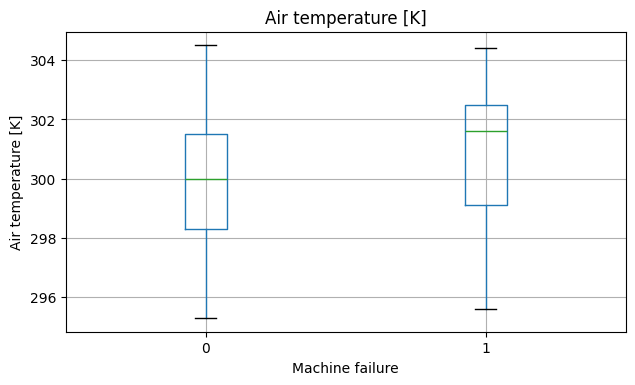

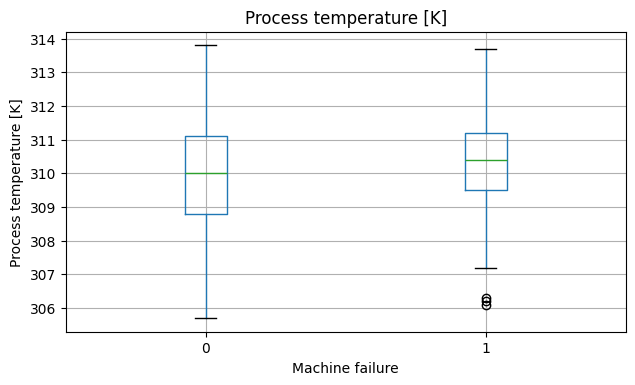

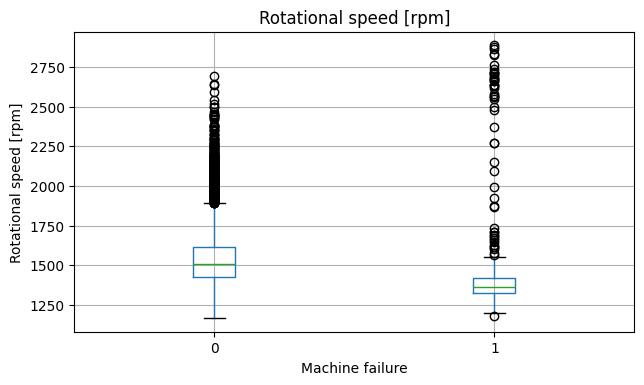

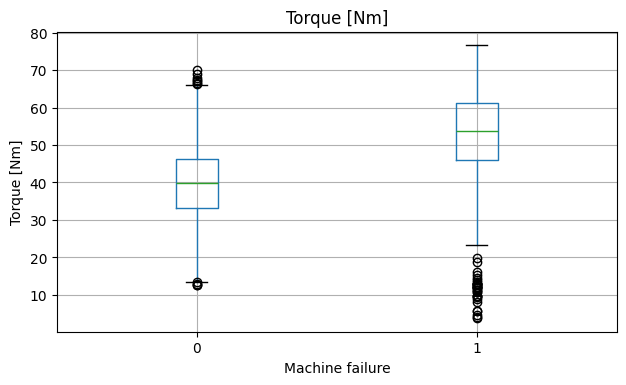

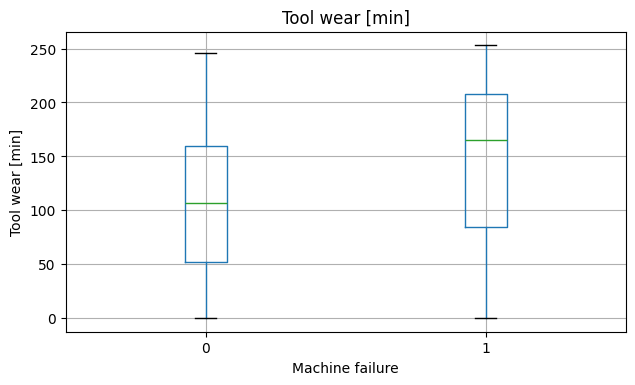

In [15]:
for feature in features:
    fig, ax = plt.subplots(figsize=(7, 4))
    ai4i.boxplot(column=feature, by="Machine failure", ax=ax)
    ax.set_title(feature)
    fig.suptitle("")
    ax.set_xlabel("Machine failure")
    ax.set_ylabel(feature)
    plt.show()

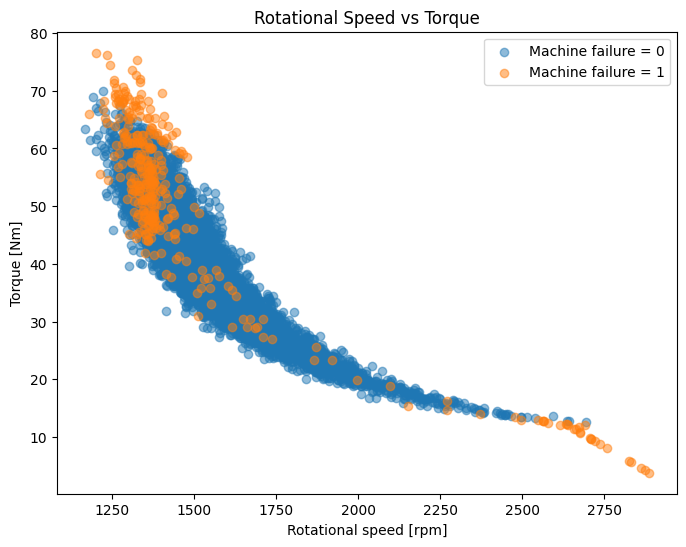

In [16]:
plt.figure(figsize=(8, 6))

for failure_value in [0, 1]:
    subset = ai4i[ai4i["Machine failure"] == failure_value]
    plt.scatter(
        subset["Rotational speed [rpm]"],
        subset["Torque [Nm]"],
        alpha=0.5,
        label=f"Machine failure = {failure_value}",
    )

plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.title("Rotational Speed vs Torque")
plt.legend()
plt.show()

In [17]:
# Feature engineering (used for interpretation only)
ai4i["Power [W]"] = ai4i["Torque [Nm]"] * ai4i["Rotational speed [rpm]"] * 2 * np.pi / 60

ai4i.groupby("Machine failure")["Power [W]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,6244.547534,1011.394393,3515.033772,5549.309263,6243.046225,6952.051327,8998.024015
1,339.0,7282.819485,1851.137977,1148.440610,6669.056661,7611.429737,8548.854805,10469.923005


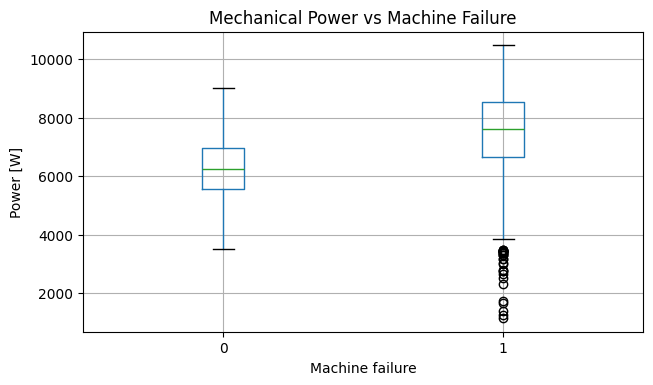

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ai4i.boxplot(column="Power [W]", by="Machine failure", ax=ax)
ax.set_title("Mechanical Power vs Machine Failure")
fig.suptitle("")
ax.set_xlabel("Machine failure")
ax.set_ylabel("Power [W]")
plt.show()

In [19]:
ai4i.groupby("PWF")["Power [W]"].describe()

,count,mean,std,min,25%,50%,75%,max
PWF,,,,,,,,
0,9905.0,6270.421649,1025.032868,3515.033772,5563.760590,6266.388258,6988.472858,8998.024015
1,95.0,7251.822098,3087.365724,1148.440610,3436.148381,9100.377103,9386.497654,10469.923005


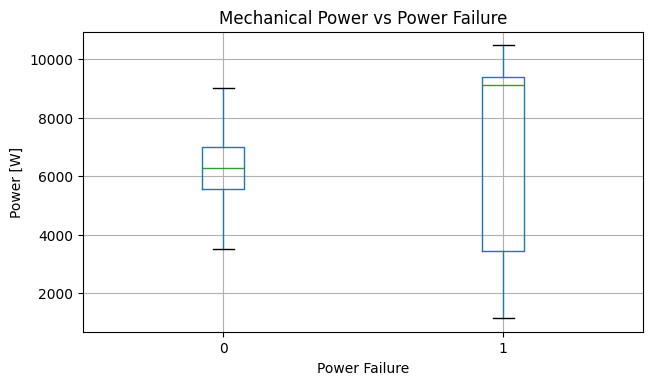

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ai4i.boxplot(column="Power [W]", by="PWF", ax=ax)
ax.set_title("Mechanical Power vs Power Failure")
fig.suptitle("")
ax.set_xlabel("Power Failure")
ax.set_ylabel("Power [W]")
plt.show()

### Correlation between operating variables

Two pairs of variables move together strongly: rotational speed and torque, and air and process temperature. A reading can therefore be unusual even when no single variable is extreme, for example normal torque at a speed where torque is normally much lower. This matters for model choice in Section 5.

In [21]:
ai4i[features].corr().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.00,0.88,0.02,-0.01,0.01
Process temperature [K],0.88,1.00,0.02,-0.01,0.01
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00
Tool wear [min],0.01,0.01,0.00,-0.00,1.00


## 3. Baseline Anomaly-Detection Model: Isolation Forest V1

Isolation Forest was selected as the first model because it can identify unusual multivariate observations without using machine-failure labels.

The first model includes product type together with the five operational variables. Its anomaly score is converted so that a higher value represents a more unusual operating condition. Machine-failure labels are excluded from the feature matrix and used only after ranking.

In [22]:
model_features = ["Type"] + features

X = pd.get_dummies(ai4i[model_features].copy(), columns=["Type"], drop_first=False)
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,False,True
1,298.2,308.7,1408,46.3,3,False,True,False
2,298.1,308.5,1498,49.4,5,False,True,False
3,298.2,308.6,1433,39.5,7,False,True,False
4,298.2,308.7,1408,40.0,9,False,True,False


In [23]:
iso_model = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE)
iso_model.fit(X)

ai4i["anomaly_score"] = -iso_model.score_samples(X)

In [24]:
top_anomalies = ai4i.sort_values("anomaly_score", ascending=False).head(20).copy()
top_anomalies["Rank"] = range(1, 21)

top_anomalies[[
    "Rank", "UDI", "Product ID", "Type", *features, "Power [W]",
    "anomaly_score", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF",
]]

,Rank,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],anomaly_score,Machine failure,TWF,HDF,PWF,OSF,RNF
887,1,888,H30301,H,295.7,306.2,2161,16.5,105,3733.939948,0.691484,0,0,0,0,0,0
5647,2,5648,H35061,H,302.5,311.8,2370,14.7,198,3648.331549,0.686891,0,0,0,0,0,0
1209,3,1210,H30623,H,297.0,308.1,2540,13.3,98,3537.642767,0.685271,0,0,0,0,0,0
901,4,902,H30315,H,295.6,306.1,1256,62.3,142,8194.195174,0.683033,0,0,0,0,0,0
5152,5,5153,L52332,L,304.3,313.5,2643,12.7,21,3515.033772,0.680817,0,0,0,0,0,0
8114,6,8115,H37528,H,300.4,311.8,2496,13.5,5,3528.636869,0.679953,0,0,0,0,0,0
4997,7,4998,M19857,M,303.6,312.8,2659,11.4,26,3174.328049,0.678075,1,0,0,1,0,0
5127,8,5128,M19987,M,304.3,313.5,2245,15.1,172,3549.947339,0.677741,0,0,0,0,0,0
847,9,848,L48027,L,296.4,307.4,2833,5.6,213,1661.357971,0.676336,1,0,0,1,0,0
1234,10,1235,H30648,H,297.2,308.5,2440,14.0,166,3577.226835,0.675721,0,0,0,0,0,0


In [25]:
ranking_evaluation_v1 = evaluate_ranking(ai4i, "anomaly_score")
ranking_evaluation_v1

,Top N,Failures Found,Failure Rate (%),Recall (%),Enrichment vs Baseline
0,20,10,50.0,2.9,14.7
1,50,14,28.0,4.1,8.3
2,100,24,24.0,7.1,7.1
3,200,38,19.0,11.2,5.6
4,339,52,15.3,15.3,4.5
5,500,57,11.4,16.8,3.4
6,1000,79,7.9,23.3,2.3


In [26]:
ai4i["Type"].value_counts(normalize=True) * 100

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

In [27]:
top_anomalies["Type"].value_counts()

Type
H    10
M     6
L     4
Name: count, dtype: int64

## 4. Model Refinement: Isolation Forest V2 (Operational Features Only)

Inspection of the V1 results showed that **Type H products make up about 10% of the dataset but 50% of V1's Top 20**. V1 was partly detecting the *rarity of a product category* rather than unusual operating behaviour, which is a form of false positive that would waste technician time.

The model was refined by removing product type. V2 uses only the five operational variables.

In [28]:
X_v2 = ai4i[features].copy()

iso_model_v2 = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE)
iso_model_v2.fit(X_v2)

ai4i["anomaly_score_v2"] = -iso_model_v2.score_samples(X_v2)

In [29]:
top20_v1 = ai4i.sort_values("anomaly_score", ascending=False).head(20)
top20_v2 = ai4i.sort_values("anomaly_score_v2", ascending=False).head(20)

type_comparison = pd.DataFrame({
    "Overall Dataset (%)": ai4i["Type"].value_counts(normalize=True) * 100,
    "V1 Top 20 (%)": top20_v1["Type"].value_counts(normalize=True) * 100,
    "V2 Top 20 (%)": top20_v2["Type"].value_counts(normalize=True) * 100,
}).reindex(["L", "M", "H"]).fillna(0).round(1)

type_comparison

,Overall Dataset (%),V1 Top 20 (%),V2 Top 20 (%)
Type,,,
L,60.0,20.0,55.0
M,30.0,30.0,35.0
H,10.0,50.0,10.0


In [30]:
ranking_evaluation_v2 = evaluate_ranking(ai4i, "anomaly_score_v2")

v1_v2_comparison = pd.DataFrame({
    "Top N": TOP_N_VALUES,
    "V1 Failures Found": ranking_evaluation_v1["Failures Found"],
    "V2 Failures Found": ranking_evaluation_v2["Failures Found"],
})
v1_v2_comparison

,Top N,V1 Failures Found,V2 Failures Found
0,20,10,9
1,50,14,18
2,100,24,33
3,200,38,43
4,339,52,54
5,500,57,70
6,1000,79,120


Saved prism_outputs/charts/01_v1_vs_v2_product_type.png


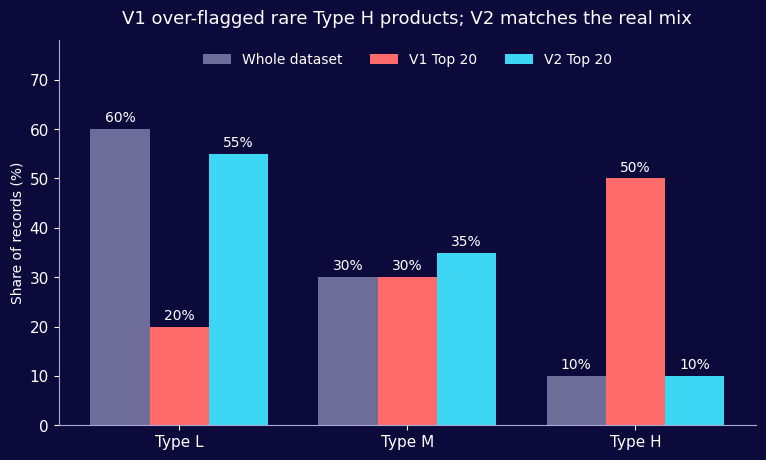

In [31]:
fig, ax = deck_axes(figsize=(9, 5))
labels = ["Type L", "Type M", "Type H"]
x = np.arange(3)
width = 0.26
series = [
    ("Whole dataset", type_comparison["Overall Dataset (%)"], DECK["grey"]),
    ("V1 Top 20", type_comparison["V1 Top 20 (%)"], DECK["red"]),
    ("V2 Top 20", type_comparison["V2 Top 20 (%)"], DECK["cyan"]),
]
for i, (name, values, colour) in enumerate(series):
    bars = ax.bar(x + (i - 1) * width, values, width, label=name, color=colour)
    ax.bar_label(bars, fmt="%.0f%%", color=DECK["fg"], fontsize=10, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Share of records (%)")
ax.set_ylim(0, 78)
ax.set_title("V1 over-flagged rare Type H products; V2 matches the real mix", fontsize=13, pad=12)
style_legend(ax, loc="upper center", ncol=3)
save_chart(fig, "01_v1_vs_v2_product_type")
plt.show()

V2's Top 20 now matches the product mix of the full dataset. V1 found one more failure in its Top 20 (10 vs 9), but V2 finds substantially more failures further down the list (33 vs 24 in the Top 100, and 120 vs 79 in the Top 1,000), so removing product type was the right call.

## 5. Benchmarking Against Simpler and Alternative Methods

A model is only worth its complexity if it beats simpler approaches that an operations team could already use. Every method below is **unsupervised**: none of them uses failure labels to score records. Labels are used only to evaluate the rankings afterwards.

| Method | How it ranks records |
|---|---|
| **Random review** | Expected failures if records were reviewed in arbitrary order |
| **Single-variable threshold** | Most extreme single reading (largest standardised deviation on any one variable). This mimics a conventional per-sensor alert. |
| **Extreme-reading count** | Number of variables outside their 5th–95th percentile, tie-broken by the most extreme percentile |
| **Isolation Forest V1 / V2** | Sections 3 and 4 |
| **Local Outlier Factor** | Density-based: how isolated a record is from its 50 nearest neighbours |
| **Mahalanobis distance** | Distance from normal operation that accounts for how variables move together (e.g. speed and torque). It flags readings that are extreme *or* an unusual combination. |

In [32]:
def fit_prism(reference_df, feature_list=features):
    """Fit the Mahalanobis model on reference data (no labels used)."""
    mean = reference_df[feature_list].mean()
    std = reference_df[feature_list].std()
    z = (reference_df[feature_list] - mean) / std
    precision = np.linalg.inv(np.cov(z.T))
    return {
        "features": list(feature_list),
        "mean": mean,
        "std": std,
        "precision": precision,
        "reference_sorted": {f: np.sort(reference_df[f].values) for f in feature_list},
    }


def standardise(model, df):
    return ((df[model["features"]] - model["mean"]) / model["std"]).values


def prism_score(model, df):
    """Squared Mahalanobis distance: higher = further from normal operation."""
    z = standardise(model, df)
    return np.einsum("ij,jk,ik->i", z, model["precision"], z)

In [33]:
baseline_rate = ai4i["Machine failure"].mean()
z_all = (ai4i[features] - ai4i[features].mean()) / ai4i[features].std()
pct_all = ai4i[features].rank(pct=True)

benchmark_scores = {
    "Single-variable threshold": z_all.abs().max(axis=1),
    "Extreme-reading count": (
        ((pct_all <= 0.05) | (pct_all >= 0.95)).sum(axis=1)
        + np.maximum(pct_all, 1 - pct_all).max(axis=1)
    ),
    "Isolation Forest V1": ai4i["anomaly_score"],
    "Isolation Forest V2": ai4i["anomaly_score_v2"],
    "Local Outlier Factor": -LocalOutlierFactor(n_neighbors=50)
        .fit(z_all).negative_outlier_factor_,
    "Mahalanobis distance": prism_score(fit_prism(ai4i), ai4i),
}

benchmark_n = [20, 100, 500, 1000]
benchmark = pd.DataFrame(
    {"Random review (expected)": [round(n * baseline_rate, 1) for n in benchmark_n]},
    index=[f"Top {n}" for n in benchmark_n],
)
for name, score in benchmark_scores.items():
    benchmark[name] = [failures_found(ai4i, score, n) for n in benchmark_n]

print("Failures found in each Top-N list (339 failures in total)")
benchmark.T

Failures found in each Top-N list (339 failures in total)


,Top 20,Top 100,Top 500,Top 1000
Random review (expected),0.7,3.4,17.0,33.9
Single-variable threshold,18.0,32.0,97.0,143.0
Extreme-reading count,9.0,25.0,97.0,120.0
Isolation Forest V1,10.0,24.0,57.0,79.0
Isolation Forest V2,9.0,33.0,70.0,120.0
Local Outlier Factor,11.0,47.0,127.0,167.0
Mahalanobis distance,17.0,42.0,142.0,187.0


### Is Isolation Forest stable?

Isolation Forest is randomised, so its ranking depends on the random seed. Re-running V2 with ten different seeds shows how much the results move.

In [34]:
seed_rows = []
for seed in range(10):
    model = IsolationForest(n_estimators=300, contamination="auto", random_state=seed).fit(X_v2)
    score = -model.score_samples(X_v2)
    seed_rows.append({f"Top {n}": failures_found(ai4i, score, n) for n in [20, 100, 1000]})

seed_stability = pd.DataFrame(seed_rows)
seed_stability.agg(["min", "mean", "max"]).round(1)

,Top 20,Top 100,Top 1000
min,9.0,34.0,116.0
mean,12.4,35.5,122.3
max,14.0,37.0,130.0


### Findings

- **Mahalanobis distance is the only method at or near the top at every cut-off.** It finds the most failures in the Top 500 and Top 1,000, is one behind the best in the Top 20, and second to Local Outlier Factor in the Top 100. It beats Isolation Forest V2 at every cut-off.
- **The single-variable threshold does well at the very top of the list but falls behind further down** (143 vs 187 failures in the Top 1,000), because it judges each sensor on its own. Mahalanobis distance weighs all five readings together, in the context of how they normally move with each other, which supports Prism's argument that readings should be judged together rather than one sensor at a time.
- **Isolation Forest results depend on the random seed.** With seed 42, V2 found 9 failures in the Top 20 and 33 in the Top 100, at or below the low end of ten other seeds (9–14 and 34–37). Mahalanobis distance is deterministic: the same data always produces the same ranking, which matters when a technician asks "why is this record ranked here?"
- Local Outlier Factor is competitive in the Top 100 but falls behind further down the list, depends on a tuning parameter (number of neighbours), and is harder to explain to a technician.

Because model selection used the same failure labels we report results on, Section 6 checks the winner on records the model has never seen.

Saved prism_outputs/charts/02_benchmark_capture_curve.png


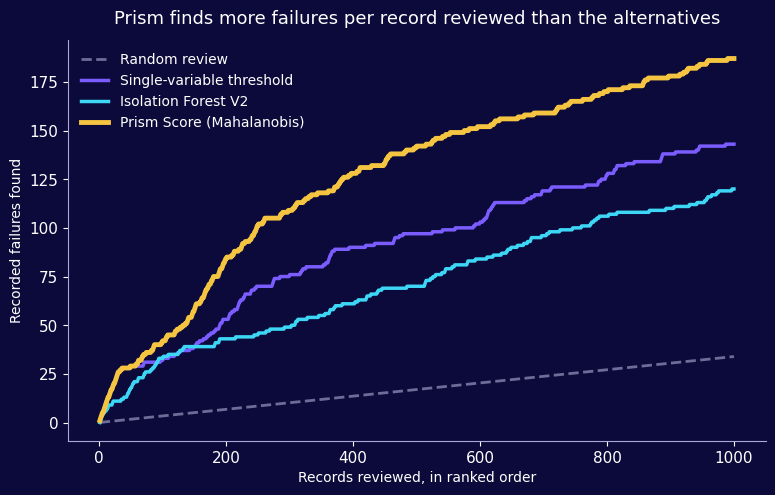

In [35]:
capture_n = np.arange(1, 1001)

def capture_curve(score):
    order = pd.Series(np.asarray(score), index=ai4i.index).sort_values(ascending=False, kind="mergesort").index
    return ai4i.loc[order, "Machine failure"].cumsum().values[:1000]

fig, ax = deck_axes(figsize=(9, 5.2))
ax.plot(capture_n, capture_n * baseline_rate, color=DECK["grey"], lw=2, ls="--", label="Random review")
ax.plot(capture_n, capture_curve(benchmark_scores["Single-variable threshold"]), color=DECK["purple"], lw=2.5, label="Single-variable threshold")
ax.plot(capture_n, capture_curve(benchmark_scores["Isolation Forest V2"]), color=DECK["cyan"], lw=2.5, label="Isolation Forest V2")
ax.plot(capture_n, capture_curve(benchmark_scores["Mahalanobis distance"]), color=DECK["yellow"], lw=3.5, label="Prism Score (Mahalanobis)")
ax.set_xlabel("Records reviewed, in ranked order")
ax.set_ylabel("Recorded failures found")
ax.set_title("Prism finds more failures per record reviewed than the alternatives", fontsize=13, pad=12)
style_legend(ax, loc="upper left")
save_chart(fig, "02_benchmark_capture_curve")
plt.show()

## 6. Holdout Check on Unseen Records

To check that Mahalanobis distance did not win by chance, the data is split 50/50 three times. Each model is fitted on one half and then scores the **other half, which it has never seen**. This is also closer to deployment, where the model is fitted on historical data and then scores new readings.

In [36]:
holdout_rows = []
for split_seed in [0, 1, 2]:
    fit_half, test_half = train_test_split(
        ai4i, test_size=0.5, random_state=split_seed, stratify=ai4i["Machine failure"]
    )

    prism_holdout = prism_score(fit_prism(fit_half), test_half)

    iso_holdout = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE)
    iso_holdout.fit(fit_half[features])
    iso_scores = -iso_holdout.score_samples(test_half[features])

    z_test = (test_half[features] - fit_half[features].mean()) / fit_half[features].std()
    single_scores = z_test.abs().max(axis=1)

    for name, score in [
        ("Prism Score (Mahalanobis)", prism_holdout),
        ("Isolation Forest V2", iso_scores),
        ("Single-variable threshold", single_scores),
    ]:
        row = {"Split": split_seed, "Method": name}
        for n in [10, 50, 500]:
            row[f"Top {n} of 5,000"] = failures_found(test_half, score, n)
        holdout_rows.append(row)

holdout_results = pd.DataFrame(holdout_rows)
holdout_results.pivot_table(index="Method", columns="Split", values="Top 500 of 5,000")

Split,0,1,2
Method,,,
Isolation Forest V2,65.0,59.0,69.0
Prism Score (Mahalanobis),95.0,94.0,102.0
Single-variable threshold,70.0,69.0,76.0


In [37]:
holdout_results.groupby("Method")[["Top 10 of 5,000", "Top 50 of 5,000", "Top 500 of 5,000"]].mean().round(1)

,"Top 10 of 5,000","Top 50 of 5,000","Top 500 of 5,000"
Method,,,
Isolation Forest V2,5.7,16.3,64.3
Prism Score (Mahalanobis),8.0,21.0,97.0
Single-variable threshold,8.7,15.7,71.7


On unseen records, Mahalanobis distance finds the most failures in all three splits at the Top 50 and Top 500 cut-offs, and is within one failure of the single-variable rule in the Top 10. Its advantage is not an artefact of choosing the model on the evaluation labels.

### Why physics-derived features are not used

Adding derived features such as power, the air–process temperature gap, and torque × tool wear improves results further (tested below). However, AI4I is a synthetic dataset whose failures were *generated* from rules on exactly these quantities. Including them would inflate performance in a way that may not transfer to a real factory. Prism therefore uses the five raw operating variables only, and the engineered features are left as a candidate for pilot testing with domain experts.

In [38]:
ai4i_eng = ai4i.copy()
ai4i_eng["Temp gap [K]"] = ai4i_eng["Process temperature [K]"] - ai4i_eng["Air temperature [K]"]
ai4i_eng["Strain [min Nm]"] = ai4i_eng["Torque [Nm]"] * ai4i_eng["Tool wear [min]"]
engineered = features + ["Power [W]", "Temp gap [K]", "Strain [min Nm]"]

pd.DataFrame({
    "Prism (5 raw variables)": [failures_found(ai4i, benchmark_scores["Mahalanobis distance"], n) for n in benchmark_n],
    "Mahalanobis + engineered": [failures_found(ai4i, prism_score(fit_prism(ai4i_eng, engineered), ai4i_eng), n) for n in benchmark_n],
}, index=[f"Top {n}" for n in benchmark_n]).T

,Top 20,Top 100,Top 500,Top 1000
Prism (5 raw variables),17,42,142,187
Mahalanobis + engineered,18,47,149,200


## 7. Final Model: the Prism Score

Based on Sections 5 and 6, the final Prism pipeline uses **Mahalanobis distance on the five operational variables**, referred to as the **Prism Score**.

Why this model:

- **Best evidence:** the strongest ranking overall (most failures in the Top 500 and Top 1,000, close to the best in the Top 20 and Top 100), confirmed on unseen records.
- **Deterministic:** no random seed, so rankings are reproducible and auditable.
- **Explainable:** the score decomposes by variable, which supports the "why flagged" text in Section 9.
- **Lightweight:** fitting is one matrix inversion. The whole model is five means, five standard deviations and a 5×5 matrix, so it runs on a laptop, needs no GPU, and can be exported as a small JSON file.
- **Same lesson as V2:** product type is excluded, so the score reflects operating behaviour, not product rarity.

Isolation Forest V1 and V2 are retained above to document how the model was developed.

In [39]:
prism_model = fit_prism(ai4i)

ai4i["prism_score"] = prism_score(prism_model, ai4i)
ai4i["Prism Rank"] = ai4i["prism_score"].rank(ascending=False, method="first").astype(int)
ai4i["Anomaly Percentile"] = (ai4i["prism_score"].rank(pct=True) * 100).round(2)

ai4i.sort_values("Prism Rank")[["Prism Rank", "Product ID", "prism_score", *features, "Machine failure"]].head(10)

,Prism Rank,Product ID,prism_score,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
1784,1,L48964,96.649258,298.3,308.0,2886,3.8,57,1
463,2,L47643,94.844029,297.4,308.7,2874,4.2,118,1
847,3,L48027,94.384078,296.4,307.4,2833,5.6,213,1
50,4,L47230,91.394021,298.9,309.1,2861,4.6,143,1
4296,5,L51476,91.109351,301.8,310.2,2825,5.8,215,1
4302,6,L51482,81.837234,301.7,310.1,2695,12.6,10,0
3369,7,L50549,81.046249,301.5,310.9,2760,8.0,15,1
1095,8,L48275,79.757278,296.9,307.5,2721,9.3,18,1
1391,9,L48571,78.970572,298.9,310.2,2737,8.8,142,1
7997,10,M22857,78.671492,301.0,312.2,2710,9.7,143,1


## 8. Prioritisation and Severity Tiers

Every record is ranked by its Prism Score. The rank answers the practical question: **which records should the team inspect first?**

Records are grouped into severity tiers by rank, so tier sizes are fixed and match team capacity:

- **Very High:** top 1% (100 records)
- **High:** next 4% (400 records)
- **Medium:** next 5% (500 records)
- **Low:** remaining 90%

The cut-off scores are stored with the model so new records can be tiered consistently (Section 12), and the explanations in Section 9 depend on the tier. Tiers describe operational unusualness, not failure probability or business impact.

*Change from the previous version:* tiers were previously assigned by percentile with `>=`, which put 101 records in Very High because of how the boundary rank was rounded, and the Isolation Forest High tier had a lower failure rate (9.0%) than Medium (10.0%). Rank-based tiers on the Prism Score fix both issues (see table below).

In [40]:
SEVERITY_CUTS = {"Very High": 0.01, "High": 0.05, "Medium": 0.10}
SEVERITY_ORDER = ["Very High", "High", "Medium", "Low"]

ranked_scores = np.sort(ai4i["prism_score"].values)[::-1]
severity_thresholds = {
    tier: float(ranked_scores[int(len(ai4i) * share) - 1])
    for tier, share in SEVERITY_CUTS.items()
}


def assign_severity(score):
    for tier in ["Very High", "High", "Medium"]:
        if score >= severity_thresholds[tier]:
            return tier
    return "Low"


ai4i["Anomaly Severity"] = ai4i["prism_score"].apply(assign_severity)

print("Score thresholds:", {k: round(v, 2) for k, v in severity_thresholds.items()})
ai4i["Anomaly Severity"].value_counts().reindex(SEVERITY_ORDER)

Score thresholds: {'Very High': 21.21, 'High': 9.88, 'Medium': 8.0}


Anomaly Severity
Very High     100
High          400
Medium        500
Low          9000
Name: count, dtype: int64

## 9. Explainability

Each flagged record gets a plain-language reason a technician can check in seconds:

1. **Extreme readings:** up to three variables in the top or bottom 5% of normal operation, most extreme first, e.g. *"Torque very low (bottom 0.05%)"*.
2. **Unusual combinations:** if no single reading is extreme, Prism names the variable that is most out of line with the others, e.g. *"Torque higher than expected for this rotational speed"*. This uses the conditional deviation of each variable given the others, taken directly from the Mahalanobis model.
3. **Routine variation:** records in the Low tier are labelled *"Not flagged"*. If a Low record has an extreme single reading, the text says so and notes that it is consistent with the other readings. This is the case where a per-sensor alert would fire but Prism judges the reading to be routine.

The explanation describes *what is unusual*, not *what caused a failure*. It does not claim causation.

In [41]:
SHORT_NAMES = {
    "Air temperature [K]": "Air temperature",
    "Process temperature [K]": "Process temperature",
    "Rotational speed [rpm]": "Rotational speed",
    "Torque [Nm]": "Torque",
    "Tool wear [min]": "Tool wear",
}

# Strongly correlated partner variable, used to phrase combination explanations
corr = ai4i[features].corr()
PARTNER = {}
for f in features:
    others = corr[f].drop(f).abs()
    if others.max() > 0.5:
        PARTNER[f] = others.idxmax()


def reading_shares(model, df):
    """For each reading: % of reference readings at or above it, and at or below it."""
    high, low = {}, {}
    for f in model["features"]:
        ref = model["reference_sorted"][f]
        n = len(ref)
        high[f] = (n - np.searchsorted(ref, df[f].values, side="left")) / n * 100
        low[f] = np.searchsorted(ref, df[f].values, side="right") / n * 100
    return pd.DataFrame(high, index=df.index), pd.DataFrame(low, index=df.index)


def conditional_deviation(model, df):
    """How far each variable sits from what the other variables would predict (in SDs)."""
    z = standardise(model, df)
    P = model["precision"]
    return pd.DataFrame((z @ P) / np.sqrt(np.diag(P)), columns=model["features"], index=df.index)


def fmt_share(x):
    return f"{max(x, 0.01):.2g}%"


def explain_record(high_row, low_row, cond_row, severity, max_reasons=3):
    """Return (explanation text, list of variables mentioned)."""
    reasons = []
    for f in features:
        if high_row[f] <= 5:
            reasons.append((high_row[f], f, f"{SHORT_NAMES[f]} very high (top {fmt_share(high_row[f])})"))
        elif low_row[f] <= 5:
            reasons.append((low_row[f], f, f"{SHORT_NAMES[f]} very low (bottom {fmt_share(low_row[f])})"))

    reasons.sort(key=lambda r: r[0])
    chosen = reasons[:max_reasons]

    if severity == "Low":
        if chosen:
            return ("Not flagged: " + "; ".join(r[2] for r in chosen)
                    + ", but consistent with the other readings"), [r[1] for r in chosen]
        return "Not flagged: routine variation", []

    if chosen:
        return "; ".join(r[2] for r in chosen), [r[1] for r in chosen]

    f = cond_row.abs().idxmax()
    direction = "higher" if cond_row[f] > 0 else "lower"
    partner = PARTNER.get(f)
    context = f"for this {SHORT_NAMES[partner].lower()}" if partner else "given the other readings"
    mentioned = [f] + ([partner] if partner else [])
    return f"Unusual combination: {SHORT_NAMES[f].lower()} {direction} than expected {context}", mentioned


def explain_all(model, df):
    high, low = reading_shares(model, df)
    cond = conditional_deviation(model, df)
    severity = pd.Series(prism_score(model, df), index=df.index).apply(assign_severity)
    results = [explain_record(high.loc[i], low.loc[i], cond.loc[i], severity.loc[i]) for i in df.index]
    text = pd.Series([r[0] for r in results], index=df.index)
    mentioned = pd.Series([r[1] for r in results], index=df.index)
    extreme_count = ((high <= 5) | (low <= 5)).sum(axis=1)
    return text, mentioned, extreme_count

In [42]:
ai4i["Why Flagged"], ai4i["Variables Mentioned"], ai4i["Extreme Features"] = explain_all(prism_model, ai4i)
ai4i["Main Driver"] = ai4i["Variables Mentioned"].apply(lambda v: SHORT_NAMES[v[0]] if v else "None")

for f in features:
    ai4i[f + "_percentile"] = (ai4i[f].rank(pct=True) * 100).round(1)

ai4i["Extreme Features"].value_counts().sort_index()

Extreme Features
0    6887
1    1684
2    1215
3     164
4      46
5       4
Name: count, dtype: int64

In [43]:
ai4i.sort_values("Prism Rank")[["Prism Rank", "Product ID", "Why Flagged"]].head(10)

,Prism Rank,Product ID,Why Flagged
1784,1,L48964,Rotational speed very high (top 0.01%); Torque very low (bottom 0.01%)
463,2,L47643,Rotational speed very high (top 0.02%); Torque very low (bottom 0.02%)
847,3,L48027,Rotational speed very high (top 0.04%); Torque very low (bottom 0.04%); Air temperature very low (bottom 2%)
50,4,L47230,Rotational speed very high (top 0.03%); Torque very low (bottom 0.03%)
4296,5,L51476,Rotational speed very high (top 0.05%); Torque very low (bottom 0.05%); Tool wear very high (top 2.5%)
4302,6,L51482,Rotational speed very high (top 0.12%); Torque very low (bottom 0.23%)
3369,7,L50549,Rotational speed very high (top 0.06%); Torque very low (bottom 0.06%)
1095,8,L48275,Rotational speed very high (top 0.08%); Torque very low (bottom 0.08%); Process temperature very low (bottom 3.4%)
1391,9,L48571,Rotational speed very high (top 0.07%); Torque very low (bottom 0.07%)
7997,10,M22857,Rotational speed very high (top 0.09%); Torque very low (bottom 0.1%)


In [44]:
# Examples of "unusual combination" records: no single extreme reading, still ranked highly
combination_examples = ai4i[
    (ai4i["Prism Rank"] <= 1000) & (ai4i["Extreme Features"] == 0)
].sort_values("Prism Rank")

print(f"Records in the Top 1,000 with no single extreme reading: {len(combination_examples)}")
combination_examples[["Prism Rank", "Product ID", "Why Flagged", "Machine failure"]].head(8)

Records in the Top 1,000 with no single extreme reading: 112


,Prism Rank,Product ID,Why Flagged,Machine failure
6333,353,M21193,Unusual combination: torque lower than expected for this rotational speed,0
4475,376,L51655,Unusual combination: air temperature higher than expected for this process temperature,1
7978,415,L55158,Unusual combination: process temperature higher than expected for this air temperature,0
7877,426,L55057,Unusual combination: process temperature higher than expected for this air temperature,0
7493,437,L54673,Unusual combination: process temperature higher than expected for this air temperature,0
4547,457,M19407,Unusual combination: air temperature higher than expected for this process temperature,0
575,473,M15435,Unusual combination: air temperature lower than expected for this process temperature,0
7907,489,L55087,Unusual combination: process temperature higher than expected for this air temperature,0


### Do the explanations point at the right variables?

As a sanity check, for recorded failures in the Top 100 we compare the variables named in the explanation with the variables physically linked to each failure type in the AI4I documentation:

| Failure type | Linked variables |
|---|---|
| Tool wear failure (TWF) | tool wear |
| Heat dissipation failure (HDF) | air temperature, process temperature, rotational speed |
| Power failure (PWF) | torque, rotational speed |
| Overstrain failure (OSF) | torque, tool wear |

Random failures (RNF) are excluded because they have no physical driver.

In [45]:
FAILURE_DRIVERS = {
    "TWF": {"Tool wear [min]"},
    "HDF": {"Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]"},
    "PWF": {"Torque [Nm]", "Rotational speed [rpm]"},
    "OSF": {"Torque [Nm]", "Tool wear [min]"},
}

def explanation_matches(row):
    types = [t for t in FAILURE_DRIVERS if row[t] == 1]
    if not types:
        return np.nan
    linked = set().union(*(FAILURE_DRIVERS[t] for t in types))
    return float(bool(linked & set(row["Variables Mentioned"])))

top100_failures = ai4i[(ai4i["Prism Rank"] <= 100) & (ai4i["Machine failure"] == 1)]
matches = top100_failures.apply(explanation_matches, axis=1).dropna()
print(f"Explanation names a physically linked variable for {int(matches.sum())} of {len(matches)} "
      f"typed failures in the Top 100 ({matches.mean():.0%}).")

Explanation names a physically linked variable for 42 of 42 typed failures in the Top 100 (100%).


## 10. Validation and Impact

The final ranking is evaluated against recorded machine failures, which were never used to fit or score the model.

In [46]:
final_severity_summary = (
    ai4i.groupby("Anomaly Severity")
    .agg(Total_Records=("Machine failure", "count"),
         Failures=("Machine failure", "sum"),
         Failure_Rate=("Machine failure", "mean"))
    .reindex(SEVERITY_ORDER)
)
final_severity_summary["Failure Rate (%)"] = (final_severity_summary["Failure_Rate"] * 100).round(1)
final_severity_summary["Enrichment vs Baseline"] = (final_severity_summary["Failure_Rate"] / baseline_rate).round(1)
final_severity_summary = final_severity_summary[["Total_Records", "Failures", "Failure Rate (%)", "Enrichment vs Baseline"]]
final_severity_summary

,Total_Records,Failures,Failure Rate (%),Enrichment vs Baseline
Anomaly Severity,,,,
Very High,100,42,42.0,12.4
High,400,100,25.0,7.4
Medium,500,45,9.0,2.7
Low,9000,152,1.7,0.5


Saved prism_outputs/charts/03_severity_tiers.png


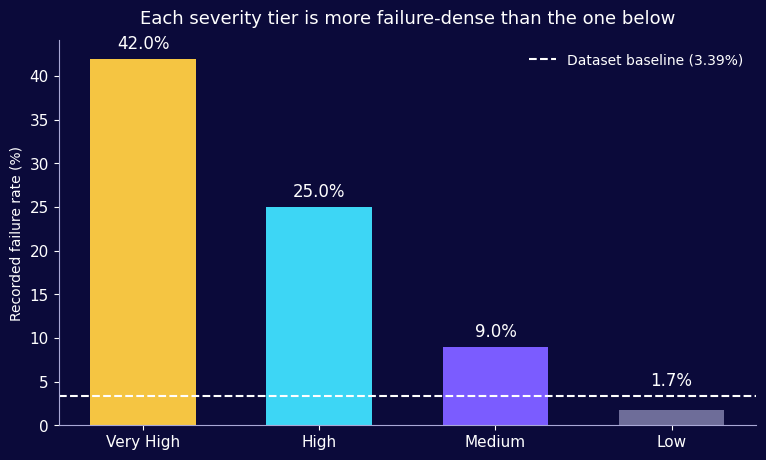

In [47]:
fig, ax = deck_axes(figsize=(9, 5))
colours = [DECK["yellow"], DECK["cyan"], DECK["purple"], DECK["grey"]]
rates = final_severity_summary["Failure Rate (%)"]
ax.bar(SEVERITY_ORDER, rates, color=colours, width=0.6)
for i, rate in enumerate(rates):
    label_y = max(rate, baseline_rate * 100) + 1.2  # keep labels clear of the baseline line
    ax.text(i, label_y, f"{rate:.1f}%", color=DECK["fg"], fontsize=12, ha="center")
ax.axhline(baseline_rate * 100, color=DECK["fg"], ls="--", lw=1.5, label=f"Dataset baseline ({baseline_rate:.2%})")
style_legend(ax, loc="upper right")
ax.set_ylabel("Recorded failure rate (%)")
ax.set_title("Each severity tier is more failure-dense than the one below", fontsize=13, pad=12)
save_chart(fig, "03_severity_tiers")
plt.show()

In [48]:
final_ranking_evaluation = evaluate_ranking(ai4i, "prism_score")
final_ranking_evaluation

,Top N,Failures Found,Failure Rate (%),Recall (%),Enrichment vs Baseline
0,20,17,85.0,5.0,25.1
1,50,29,58.0,8.6,17.1
2,100,42,42.0,12.4,12.4
3,200,84,42.0,24.8,12.4
4,339,117,34.5,34.5,10.2
5,500,142,28.4,41.9,8.4
6,1000,187,18.7,55.2,5.5


Saved prism_outputs/charts/04_topn_failure_rate.png


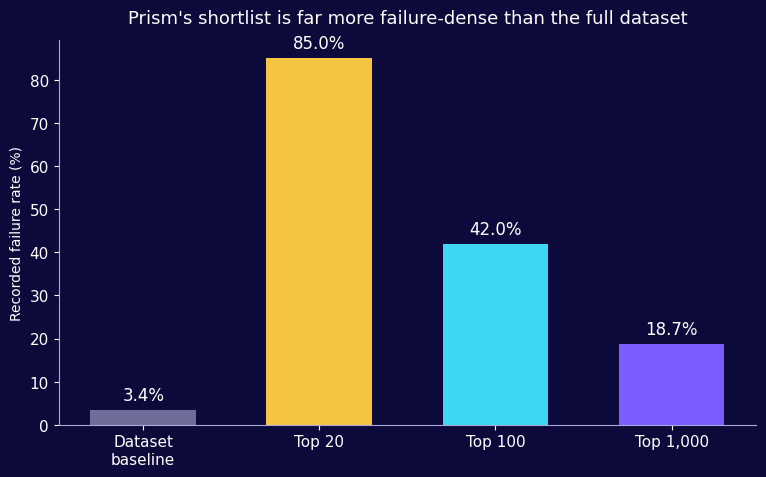

In [49]:
fig, ax = deck_axes(figsize=(9, 5))
cuts = [20, 100, 1000]
rates = final_ranking_evaluation.set_index("Top N").loc[cuts, "Failure Rate (%)"]
labels = ["Dataset\nbaseline"] + [f"Top {n:,}" for n in cuts]
values = [baseline_rate * 100] + list(rates)
bars = ax.bar(labels, values, color=[DECK["grey"], DECK["yellow"], DECK["cyan"], DECK["purple"]], width=0.6)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in values], color=DECK["fg"], fontsize=12, padding=4)
ax.set_ylabel("Recorded failure rate (%)")
ax.set_title("Prism's shortlist is far more failure-dense than the full dataset", fontsize=13, pad=12)
save_chart(fig, "04_topn_failure_rate")
plt.show()

### Which failure types does Prism catch?

In [50]:
failure_type_names = {
    "TWF": "Tool wear", "HDF": "Heat dissipation", "PWF": "Power",
    "OSF": "Overstrain", "RNF": "Random",
}
capture_rows = []
for code_, name in failure_type_names.items():
    total = int(ai4i[code_].sum())
    capture_rows.append({
        "Failure Type": name,
        "Total Recorded": total,
        "In Top 500": int(ai4i.loc[ai4i["Prism Rank"] <= 500, code_].sum()),
        "In Top 1,000": int(ai4i.loc[ai4i["Prism Rank"] <= 1000, code_].sum()),
    })
failure_capture = pd.DataFrame(capture_rows)
failure_capture["Captured in Top 1,000 (%)"] = (failure_capture["In Top 1,000"] / failure_capture["Total Recorded"] * 100).round(0)
failure_capture

,Failure Type,Total Recorded,In Top 500,"In Top 1,000","Captured in Top 1,000 (%)"
0,Tool wear,46,8,16,35.0
1,Heat dissipation,115,20,36,31.0
2,Power,95,95,95,100.0
3,Overstrain,98,41,64,65.0
4,Random,19,1,2,11.0


Saved prism_outputs/charts/05_failure_type_capture.png


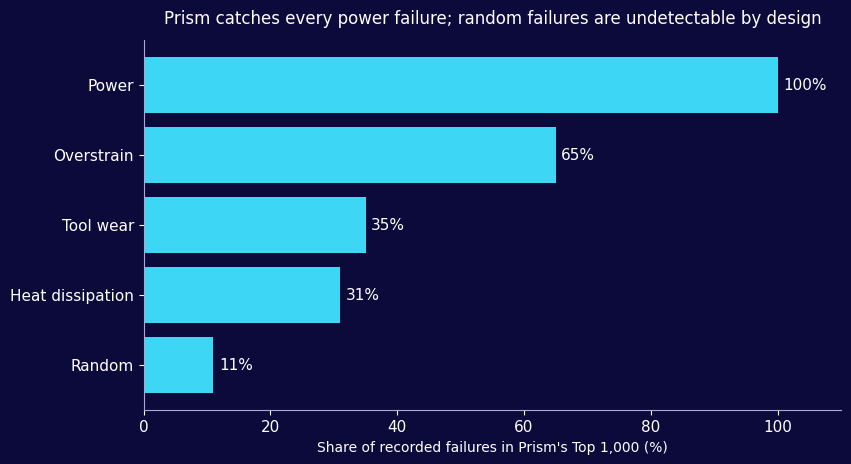

In [51]:
fig, ax = deck_axes(figsize=(9, 4.8))
fc = failure_capture.sort_values("Captured in Top 1,000 (%)")
bars = ax.barh(fc["Failure Type"], fc["Captured in Top 1,000 (%)"], color=DECK["cyan"])
ax.bar_label(bars, fmt="%.0f%%", color=DECK["fg"], fontsize=11, padding=4)
ax.set_xlim(0, 110)
ax.set_xlabel("Share of recorded failures in Prism's Top 1,000 (%)")
ax.set_title("Prism catches every power failure; random failures are undetectable by design", fontsize=12, pad=12)
save_chart(fig, "05_failure_type_capture")
plt.show()

Power failures and overstrain failures produce clearly abnormal operating conditions, so Prism catches them well. Heat-dissipation and tool-wear failures happen under more ordinary-looking readings and are harder for any unsupervised method. Random failures are, by design of the dataset, unrelated to the readings, so no model should catch them.

### Impact: review effort

The practical question for a maintenance team is how much reviewing it takes to find a given number of real problems. The table compares Prism's ranked list against reviewing records in arbitrary order.

`MINUTES_PER_REVIEW` is an **illustrative assumption**, not a measured figure. Replace it with a real figure from a pilot site.

In [52]:
MINUTES_PER_REVIEW = 5  # illustrative assumption only

impact_rows = []
for n in [20, 100, 500, 1000]:
    found = failures_found(ai4i, "prism_score", n)
    random_needed = found / baseline_rate
    impact_rows.append({
        "Prism reviews": n,
        "Failures found": found,
        "Random reviews needed for same result": int(round(random_needed)),
        "Effort reduction (x)": round(random_needed / n, 1),
        "Hours saved (illustrative)": round((random_needed - n) * MINUTES_PER_REVIEW / 60, 1),
    })
impact = pd.DataFrame(impact_rows)
impact

,Prism reviews,Failures found,Random reviews needed for same result,Effort reduction (x),Hours saved (illustrative)
0,20,17,501,25.1,40.1
1,100,42,1239,12.4,94.9
2,500,142,4189,8.4,307.4
3,1000,187,5516,5.5,376.4


## 11. False Positives

The brief asks solutions to consider false positives. A record that Prism flags but that has no recorded failure is a "false positive" in the evaluation, but not necessarily a wasted inspection.

In [53]:
fp_rows = []
for n in [20, 100, 500, 1000]:
    top = ai4i[ai4i["Prism Rank"] <= n]
    fp_rows.append({"Top N": n, "Recorded failures": int(top["Machine failure"].sum()),
                    "No recorded failure": int((top["Machine failure"] == 0).sum())})
pd.DataFrame(fp_rows)

,Top N,Recorded failures,No recorded failure
0,20,17,3
1,100,42,58
2,500,142,358
3,1000,187,813


### Alerts Prism suppresses

A conventional per-sensor rule would alert on any reading in the top or bottom 5% of its range. The table compares records that would trigger such an alert with Prism's tiers.

In [54]:
single_sensor_alert = ai4i["Extreme Features"] > 0
groups = {
    "Single-sensor alert, Prism flags (Medium+)": single_sensor_alert & (ai4i["Anomaly Severity"] != "Low"),
    "Single-sensor alert, Prism says routine (Low)": single_sensor_alert & (ai4i["Anomaly Severity"] == "Low"),
    "No single-sensor alert, Prism flags (combination)": ~single_sensor_alert & (ai4i["Anomaly Severity"] != "Low"),
}
suppression = pd.DataFrame([
    {"Group": name, "Records": int(mask.sum()),
     "Recorded failures": int(ai4i.loc[mask, "Machine failure"].sum()),
     "Failure rate (%)": round(ai4i.loc[mask, "Machine failure"].mean() * 100, 1)}
    for name, mask in groups.items()
])
suppression

,Group,Records,Recorded failures,Failure rate (%)
0,"Single-sensor alert, Prism flags (Medium+)",888,183,20.6
1,"Single-sensor alert, Prism says routine (Low)",2225,91,4.1
2,"No single-sensor alert, Prism flags (combination)",112,4,3.6


**Interpretation**

- A per-sensor rule would raise **3,113 alerts** at an 8.8% failure rate. Prism escalates 888 of them (20.6% failure rate) and labels 2,225 as routine (4.1%), so a team looks at far fewer alerts and the ones it sees are about five times richer in failures.
- The trade-off is real: 91 recorded failures sit among the alerts Prism calls routine. Teams with spare capacity can review deeper into the Low tier; the ranking tells them where to stop.
- Records flagged **only** for an unusual combination have a failure rate close to the dataset baseline. In AI4I, failures are driven mainly by extreme readings, so the combination check is a safety net to test on real data rather than a proven gain here.

### Many "false alarms" are near-misses

The AI4I documentation describes the operating conditions under which each failure type occurs (power outside 3,500–9,000 W; torque × tool wear above 11,000–13,000 min·Nm depending on product type; a small air–process temperature gap at low speed; tool wear of 200–240 minutes). We check how many of Prism's flagged non-failures were operating **within 10% of one of these limits**, compared with non-failures overall.

These rules are specific to this synthetic dataset and are used for this analysis only. They are not model inputs.

In [55]:
def near_failure_limit(df, margin=0.10):
    power = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
    temp_gap = df["Process temperature [K]"] - df["Air temperature [K]"]
    strain = df["Torque [Nm]"] * df["Tool wear [min]"]
    strain_limit = df["Type"].map({"L": 11000, "M": 12000, "H": 13000})
    return (
        (power < 3500 * (1 + margin)) | (power > 9000 * (1 - margin))
        | (strain > strain_limit * (1 - margin))
        | ((temp_gap < 8.6 * (1 + margin)) & (df["Rotational speed [rpm]"] < 1380 * (1 + margin)))
        | (df["Tool wear [min]"] >= 200 * (1 - margin))
    )

ai4i["Near Failure Limit"] = near_failure_limit(ai4i)
non_failures = ai4i[ai4i["Machine failure"] == 0]

near_miss_rows = [{"Group": "All non-failure records",
                   "Near a failure limit (%)": round(non_failures["Near Failure Limit"].mean() * 100, 1)}]
for n in [100, 500, 1000]:
    fp = non_failures[non_failures["Prism Rank"] <= n]
    near_miss_rows.append({"Group": f"Prism Top {n:,} non-failures ({len(fp)})",
                           "Near a failure limit (%)": round(fp["Near Failure Limit"].mean() * 100, 1)})
near_miss = pd.DataFrame(near_miss_rows)
near_miss

,Group,Near a failure limit (%)
0,All non-failure records,33.4
1,Prism Top 100 non-failures (58),81.0
2,Prism Top 500 non-failures (358),60.1
3,"Prism Top 1,000 non-failures (813)",54.2


In [56]:
# Sensitivity: tighter 5% margin
tight = near_failure_limit(ai4i, margin=0.05)
fp100 = non_failures[non_failures["Prism Rank"] <= 100].index
print(f"Within 5% of a limit: {tight[fp100].mean():.0%} of Top-100 non-failures "
      f"vs {tight[non_failures.index].mean():.0%} of all non-failures")

Within 5% of a limit: 59% of Top-100 non-failures vs 17% of all non-failures


Saved prism_outputs/charts/06_false_positive_near_misses.png


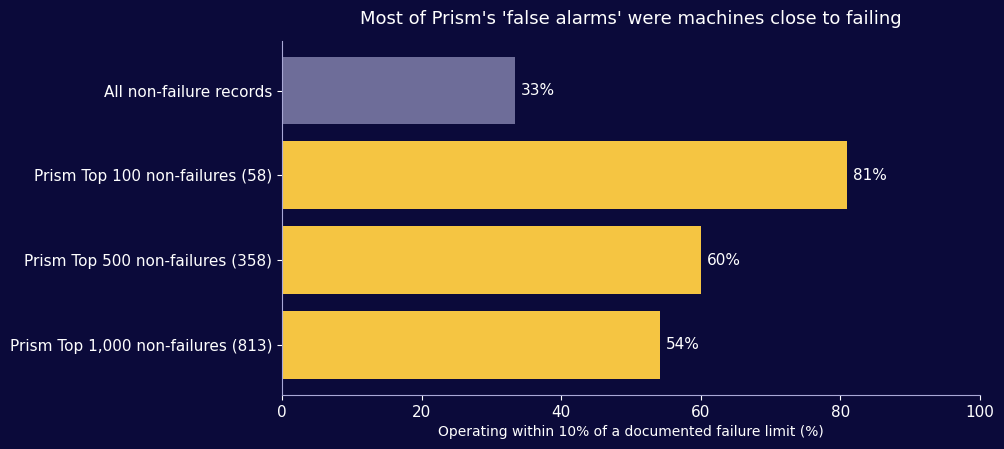

In [57]:
fig, ax = deck_axes(figsize=(9, 4.6))
nm = near_miss.iloc[::-1]
bar_colours = [DECK["yellow"]] * (len(nm) - 1) + [DECK["grey"]]
bars = ax.barh(nm["Group"], nm["Near a failure limit (%)"], color=bar_colours)
ax.bar_label(bars, fmt="%.0f%%", color=DECK["fg"], fontsize=11, padding=4)
ax.set_xlim(0, 100)
ax.set_xlabel("Operating within 10% of a documented failure limit (%)")
ax.set_title("Most of Prism's 'false alarms' were machines close to failing", fontsize=13, pad=12)
save_chart(fig, "06_false_positive_near_misses")
plt.show()

### How Prism keeps false positives manageable

1. **Fewer, better alerts.** Compared with per-sensor alerting, Prism cuts the alert list by about two-thirds and roughly doubles its hit rate.
2. **Capacity-matched tiers.** A team reviews only as deep as it has time for. The Very High tier is 100 records at a 42% failure rate.
3. **Fast dismissal.** Every flag carries a reason, so a technician can confirm or dismiss it in seconds instead of re-analysing raw data.
4. **Near-misses are useful.** Most flagged non-failures were operating close to a failure limit, which is worth knowing about before it becomes a breakdown.
5. **Next step: a feedback loop.** In the dashboard, technicians mark flags as "real issue" or "routine". Those labels can then be used to suppress known routine patterns and to measure precision on real sites.

## 12. Scoring New Records

In deployment, Prism is fitted once on historical readings and then scores each new batch without refitting. The function below takes new readings and returns a ranked, explained queue.

The four hand-written readings illustrate the four situations a technician will see:

- **Press 2**: extreme readings, ranked Very High.
- **Press 3**: no single reading is extreme, so a per-sensor alert stays silent, but the *combination* is unusual and Prism flags it.
- **Press 4**: torque is in the top 3%, so a per-sensor alert would fire, but high torque is normal at low speed and Prism ranks it as routine.
- **Press 1**: a normal reading.

In [58]:
def score_new_records(model, new_df):
    out = new_df.copy()
    out["prism_score"] = prism_score(model, out)
    out["Anomaly Severity"] = out["prism_score"].apply(assign_severity)
    out["Why Flagged"], _, out["Extreme Features"] = explain_all(model, out)
    return out.sort_values("prism_score", ascending=False)


new_batch = pd.DataFrame([
    {"Machine": "Press 1", "Air temperature [K]": 300.0, "Process temperature [K]": 310.0,
     "Rotational speed [rpm]": 1500, "Torque [Nm]": 40.0, "Tool wear [min]": 100},
    {"Machine": "Press 2", "Air temperature [K]": 300.1, "Process temperature [K]": 310.2,
     "Rotational speed [rpm]": 2700, "Torque [Nm]": 9.0, "Tool wear [min]": 60},
    {"Machine": "Press 3", "Air temperature [K]": 300.0, "Process temperature [K]": 310.0,
     "Rotational speed [rpm]": 1600, "Torque [Nm]": 55.0, "Tool wear [min]": 100},
    {"Machine": "Press 4", "Air temperature [K]": 300.0, "Process temperature [K]": 310.0,
     "Rotational speed [rpm]": 1350, "Torque [Nm]": 60.0, "Tool wear [min]": 100},
])

score_new_records(prism_model, new_batch)[["Machine", "prism_score", "Anomaly Severity", "Why Flagged"]].round(2)

,Machine,prism_score,Anomaly Severity,Why Flagged
1,Press 2,70.51,Very High,Torque very low (bottom 0.07%); Rotational speed very high (top 0.11%)
2,Press 3,14.03,High,Unusual combination: torque higher than expected for this rotational speed
3,Press 4,6.16,Low,"Not flagged: Torque very high (top 2.4%), but consistent with the other readings"
0,Press 1,0.21,Low,Not flagged: routine variation


## 13. Final Outputs and Exports

The pipeline produces:

1. **an explainable Top-10 review queue** (below);
2. **`prism_scored_records.csv`**: every record with its score, rank, severity, explanation and validation labels, which feeds the dashboard;
3. **`prism_model.json`**: the fitted model (means, standard deviations, precision matrix, severity thresholds), so new data can be scored without this notebook;
4. **evaluation tables** (benchmark, ranking evaluation, severity summary, impact); and
5. **deck-styled charts** in `prism_outputs/charts/`.

In [59]:
def get_failure_type(row):
    if row["Machine failure"] == 0 and row["failure_type_count"] == 0:
        return "None"
    names = [failure_type_names[c] + " failure" for c in failure_cols if row[c] == 1]
    if names:
        return ", ".join(names)
    return "Failure (type not recorded)"

ai4i["Failure Type"] = ai4i.apply(get_failure_type, axis=1)

final_top_anomalies = ai4i.sort_values("Prism Rank").head(10)[[
    "Prism Rank", "Product ID", "Anomaly Severity", "prism_score",
    "Why Flagged", "Machine failure", "Failure Type",
]].rename(columns={
    "prism_score": "Prism Score",
    "Machine failure": "Recorded Failure (Validation Only)",
    "Failure Type": "Failure Type (Validation Only)",
})
final_top_anomalies["Prism Score"] = final_top_anomalies["Prism Score"].round(1)
final_top_anomalies

,Prism Rank,Product ID,Anomaly Severity,Prism Score,Why Flagged,Recorded Failure (Validation Only),Failure Type (Validation Only)
1784,1,L48964,Very High,96.6,Rotational speed very high (top 0.01%); Torque very low (bottom 0.01%),1,Power failure
463,2,L47643,Very High,94.8,Rotational speed very high (top 0.02%); Torque very low (bottom 0.02%),1,Power failure
847,3,L48027,Very High,94.4,Rotational speed very high (top 0.04%); Torque very low (bottom 0.04%); Air temperature very low (bottom 2%),1,Power failure
50,4,L47230,Very High,91.4,Rotational speed very high (top 0.03%); Torque very low (bottom 0.03%),1,Power failure
4296,5,L51476,Very High,91.1,Rotational speed very high (top 0.05%); Torque very low (bottom 0.05%); Tool wear very high (top 2.5%),1,Power failure
4302,6,L51482,Very High,81.8,Rotational speed very high (top 0.12%); Torque very low (bottom 0.23%),0,None
3369,7,L50549,Very High,81.0,Rotational speed very high (top 0.06%); Torque very low (bottom 0.06%),1,Power failure
1095,8,L48275,Very High,79.8,Rotational speed very high (top 0.08%); Torque very low (bottom 0.08%); Process temperature very low (bottom 3.4%),1,Power failure
1391,9,L48571,Very High,79.0,Rotational speed very high (top 0.07%); Torque very low (bottom 0.07%),1,Power failure
7997,10,M22857,Very High,78.7,Rotational speed very high (top 0.09%); Torque very low (bottom 0.1%),1,Power failure


In [60]:
export_columns = [
    "Prism Rank", "UDI", "Product ID", "Type", *features, "Power [W]",
    "prism_score", "Anomaly Percentile", "Anomaly Severity",
    "Why Flagged", "Main Driver", "Extreme Features",
    *[f + "_percentile" for f in features],
    "anomaly_score_v2",
    "Machine failure", "Failure Type", "Near Failure Limit",
]
scored = ai4i.sort_values("Prism Rank")[export_columns]
scored.to_csv(OUTPUT_DIR / "prism_scored_records.csv", index=False)

model_export = {
    "model": "Prism Score: squared Mahalanobis distance on standardised operating variables",
    "features": prism_model["features"],
    "mean": prism_model["mean"].round(6).tolist(),
    "std": prism_model["std"].round(6).tolist(),
    "precision_matrix": np.round(prism_model["precision"], 8).tolist(),
    "severity_thresholds": severity_thresholds,
    "trained_on": "AI4I 2020 Predictive Maintenance dataset (10,000 records); failure labels not used",
}
with open(OUTPUT_DIR / "prism_model.json", "w") as fh:
    json.dump(model_export, fh, indent=2)

benchmark.T.to_csv(OUTPUT_DIR / "benchmark_failures_found.csv")
final_ranking_evaluation.to_csv(OUTPUT_DIR / "final_ranking_evaluation.csv", index=False)
final_severity_summary.to_csv(OUTPUT_DIR / "severity_summary.csv")
impact.to_csv(OUTPUT_DIR / "impact_review_effort.csv", index=False)

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(p.relative_to(OUTPUT_DIR))

benchmark_failures_found.csv
charts/01_v1_vs_v2_product_type.png
charts/02_benchmark_capture_curve.png
charts/03_severity_tiers.png
charts/04_topn_failure_rate.png
charts/05_failure_type_capture.png
charts/06_false_positive_near_misses.png
final_ranking_evaluation.csv
impact_review_effort.csv
prism_model.json
prism_scored_records.csv
severity_summary.csv


## 14. Conclusion

Prism turns 10,000 operational readings into a prioritised, explained review queue without using any failure labels to build it.

**Key results (AI4I 2020, labels used for evaluation only):**

| | Prism | Random review |
|---|---|---|
| Failures in Top 20 | 17 of 20 (85%) | 0.7 |
| Failures in Top 100 | 42 of 100 (42%) | 3.4 |
| Failures in Top 1,000 | 187 (55.2% of all failures) | 33.9 |
| Very High tier failure rate | 42.0% | 3.39% |

- **Detect:** Mahalanobis distance gave the strongest overall ranking against Isolation Forest, Local Outlier Factor and single-variable thresholds, and its advantage held on unseen records.
- **Prioritise:** rank-based severity tiers have strictly decreasing failure rates (42.0% → 25.0% → 9.0% → 1.7%).
- **Explain:** every record gets a plain-language reason; for all 42 typed failures in the Top 100, the explanation names a physically linked variable.
- **Separate routine from real:** of the 3,113 records a per-sensor alert would raise, Prism escalates 888 (20.6% failure rate) and labels 2,225 as routine (4.1%).
- **False positives:** most flagged non-failures were operating close to a documented failure limit, so they are near-misses rather than noise.

### Development journey

1. Isolation Forest V1 over-flagged rare Type H products.
2. Isolation Forest V2 removed product type and improved deeper rankings.
3. Benchmarking showed a simpler, deterministic method (Mahalanobis distance) beat both, so it became the final Prism Score.

### Limitations

- An unusual reading is not necessarily a failure, and the explanation describes what is unusual, not what caused it.
- Severity reflects statistical unusualness, not business impact.
- AI4I is a single synthetic dataset. Real operational data will be noisier, drift over time, and may not follow a single "normal" operating mode.
- Mahalanobis distance assumes one normal operating regime. Sites with several distinct modes (e.g. different products or shifts) would need one model per mode or a mixture model.
- Heat-dissipation and tool-wear failures are harder to catch from readings alone, and random failures cannot be caught.

### Recommended next steps

1. Build the operator dashboard on `prism_scored_records.csv` and test the explanations with maintenance users.
2. Add a "real issue / routine" feedback button to measure precision on real sites.
3. Validate on new or time-separated operational data from a pilot partner.
4. Incorporate asset criticality, downtime, safety and cost data to move from *most unusual* to *most important*.
5. Test physics-derived features (power, temperature gap, strain) with domain experts on real data.

Prism is a decision-support tool: it helps teams focus limited attention, while leaving investigation and action to human experts.